In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load the 10-year dataset
df = pd.read_csv('../data/air_cargo_10yr_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset loaded: {len(df):,} rows.")
display(df.head())

Dataset loaded: 657,540 rows.


,Date,Origin,Destination,Flight_Sequence,Scheduled_Flights,Base_Price_per_kg,Price_Index,Final_True_Demand,Final_Constrained_Bookings,Is_Censored,...,Price_Spot_DP10,Price_Spot_DP9,Price_Spot_DP8,Price_Spot_DP7,Price_Spot_DP6,Price_Spot_DP5,Price_Spot_DP4,Price_Spot_DP3,Price_Spot_DP2,Price_Spot_DP1
0,2016-01-01,PVG,PEK,1,1,2.6,1.179655,92813.0,92813.0,False,...,3.91,4.11,4.32,4.53,4.76,5.00,5.25,5.51,5.78,6.07
1,2016-01-02,PVG,PEK,1,1,2.6,1.007777,52932.0,52932.0,False,...,3.34,3.51,3.69,3.87,4.06,4.27,4.48,4.71,4.94,5.19
2,2016-01-03,PVG,PEK,1,1,2.6,0.813197,35966.0,35966.0,False,...,2.70,2.83,2.98,3.12,3.28,3.44,3.62,3.80,3.99,4.19
3,2016-01-04,PVG,PEK,1,1,2.6,1.265814,66472.0,66472.0,False,...,4.20,4.41,4.63,4.86,5.11,5.36,5.63,5.91,6.21,6.52
4,2016-01-05,PVG,PEK,1,1,2.6,0.888017,55216.0,55216.0,False,...,2.95,3.09,3.25,3.41,3.58,3.76,3.95,4.15,4.35,4.57


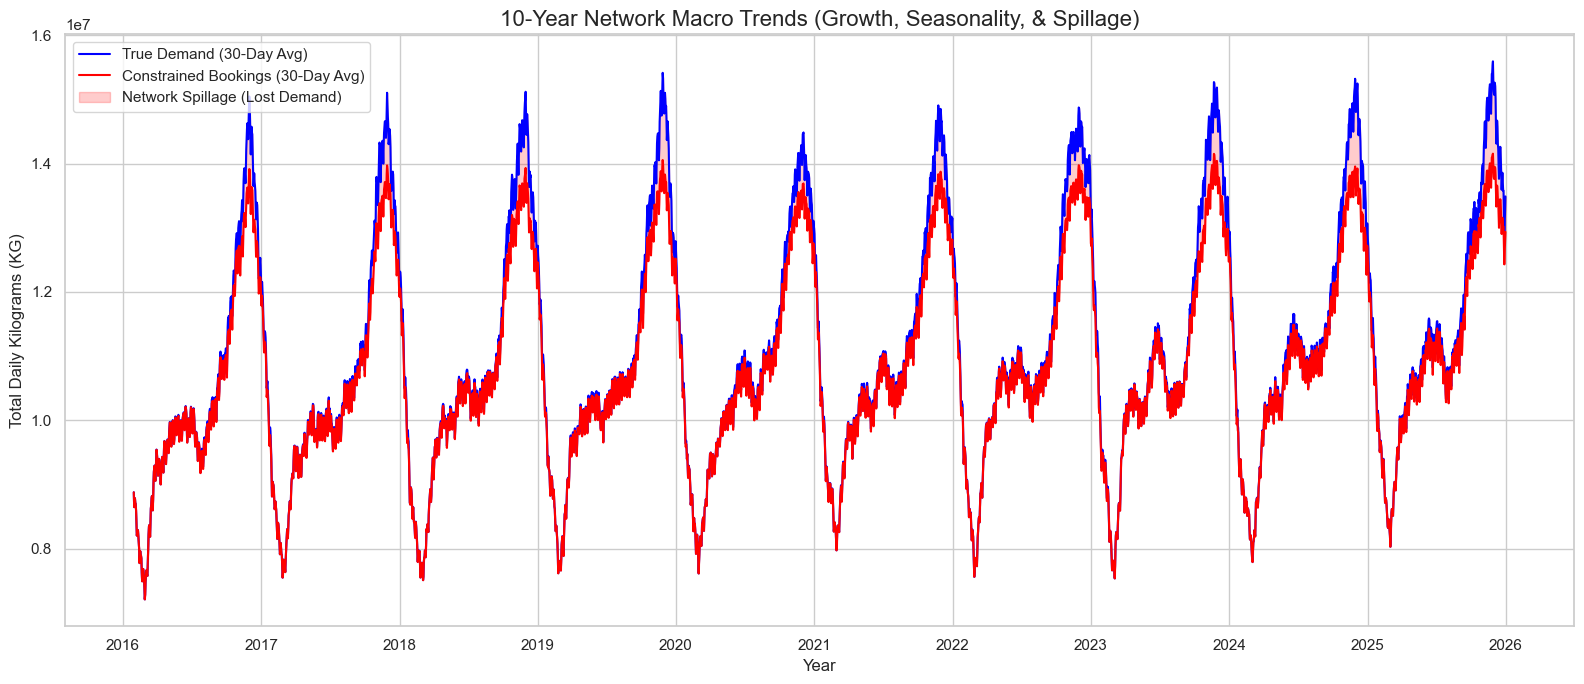

In [2]:
# Aggregate total network demand per day
daily_network = df.groupby('Date')[['Final_True_Demand', 'Final_Constrained_Bookings']].sum().reset_index()

# Calculate a 30-day moving average to smooth out the Day-of-Week noise
daily_network['True_MA30'] = daily_network['Final_True_Demand'].rolling(window=30).mean()
daily_network['Const_MA30'] = daily_network['Final_Constrained_Bookings'].rolling(window=30).mean()

plt.figure(figsize=(16, 7))
plt.plot(daily_network['Date'], daily_network['True_MA30'], label='True Demand (30-Day Avg)', color='blue')
plt.plot(daily_network['Date'], daily_network['Const_MA30'], label='Constrained Bookings (30-Day Avg)', color='red')

# Fill the gap to visually highlight spilled network demand
plt.fill_between(daily_network['Date'], daily_network['Const_MA30'], daily_network['True_MA30'], color='red', alpha=0.2, label='Network Spillage (Lost Demand)')

plt.title('10-Year Network Macro Trends (Growth, Seasonality, & Spillage)', fontsize=16)
plt.ylabel('Total Daily Kilograms (KG)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

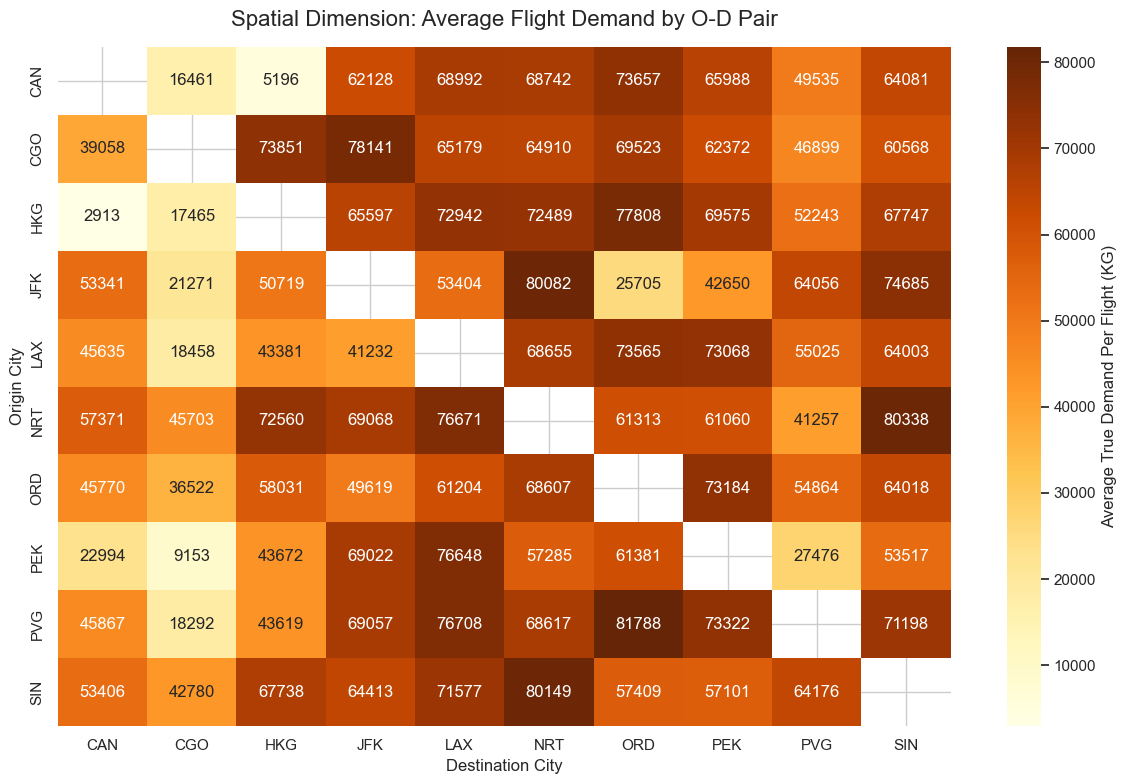

In [3]:
# Calculate average daily true demand per flight by Origin and Destination
od_summary = df.groupby(['Origin', 'Destination'])['Final_True_Demand'].mean().reset_index()

# Pivot for the heatmap
heatmap_data = od_summary.pivot(index='Origin', columns='Destination', values='Final_True_Demand')

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".0f", 
    cmap="YlOrBr", 
    cbar_kws={'label': 'Average True Demand Per Flight (KG)'}
)

plt.title('Spatial Dimension: Average Flight Demand by O-D Pair', fontsize=16, pad=15)
plt.ylabel('Origin City', fontsize=12)
plt.xlabel('Destination City', fontsize=12)
plt.tight_layout()
plt.show()

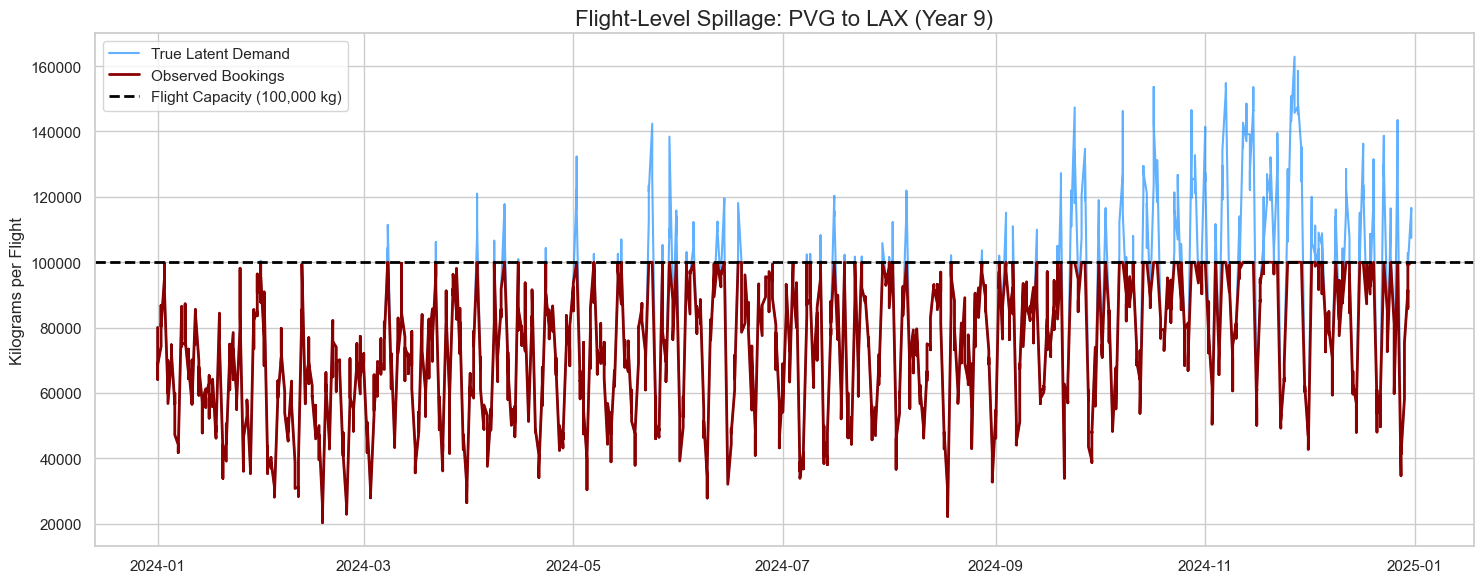

In [4]:
# Isolate 1 year of a heavy export route
pvg_lax = df[(df['Origin'] == 'PVG') & (df['Destination'] == 'LAX')].copy()
year_slice = pvg_lax[(pvg_lax['Date'] >= '2024-01-01') & (pvg_lax['Date'] <= '2024-12-31')]

plt.figure(figsize=(15, 6))
plt.plot(year_slice['Date'], year_slice['Final_True_Demand'], label='True Latent Demand', color='dodgerblue', alpha=0.7)
plt.plot(year_slice['Date'], year_slice['Final_Constrained_Bookings'], label='Observed Bookings', color='darkred', linewidth=2)

# The Hard Capacity Wall (100,000 KG)
plt.axhline(y=100000, color='black', linestyle='--', linewidth=2, label='Flight Capacity (100,000 kg)')

plt.title('Flight-Level Spillage: PVG to LAX (Year 9)', fontsize=16)
plt.ylabel('Kilograms per Flight', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

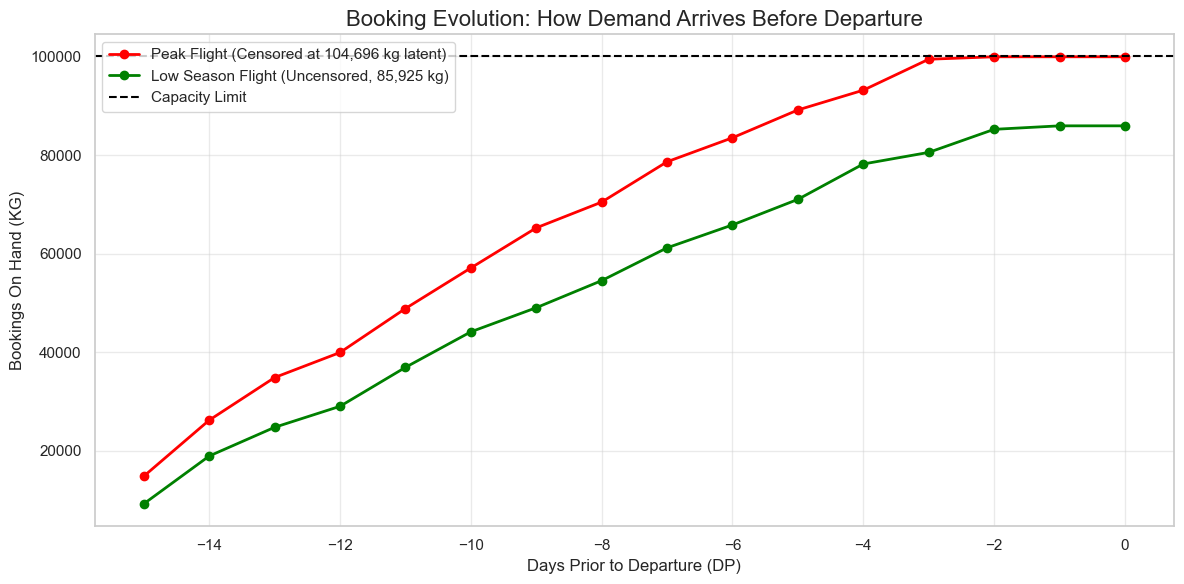

In [5]:
# Grab the columns that represent the 15-day curve: BOH_DP15 to BOH_DP1, plus the final day
curve_cols = [f'BOH_DP{i}' for i in range(-15, 0)] + ['Final_Constrained_Bookings']
x_axis = list(range(-15, 1)) # -15 to 0

# Select 3 distinct flights to showcase
# 1. A severely constrained peak-season flight
peak_flight = df[(df['Origin'] == 'PVG') & (df['Is_Censored'] == True)].iloc[100]
# 2. A low-season unconstrained flight
low_flight = df[(df['Origin'] == 'PVG') & (df['Is_Censored'] == False)].iloc[250]

plt.figure(figsize=(12, 6))

plt.plot(x_axis, peak_flight[curve_cols].values, marker='o', linewidth=2, color='red', 
         label=f"Peak Flight (Censored at {peak_flight['Final_True_Demand']:,.0f} kg latent)")

plt.plot(x_axis, low_flight[curve_cols].values, marker='o', linewidth=2, color='green', 
         label=f"Low Season Flight (Uncensored, {low_flight['Final_True_Demand']:,.0f} kg)")

# Capacity line
plt.axhline(y=100000, color='black', linestyle='--', label='Capacity Limit')

plt.title('Booking Evolution: How Demand Arrives Before Departure', fontsize=16)
plt.xlabel('Days Prior to Departure (DP)', fontsize=12)
plt.ylabel('Bookings On Hand (KG)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()